# Ensemble Attack Prediction Model with Optuna Hyperparameter Tuning

This notebook implements an ensemble model combining **XGBoost**, **CatBoost**, and **LightGBM** with **Optuna** hyperparameter optimization for attack type prediction on the NF-ToN-IoT-V2 dataset.

## Model Architecture
- **Base Models**: XGBoost, CatBoost, LightGBM
- **Ensemble Method**: Soft Voting (weighted average of prediction probabilities)
- **Hyperparameter Tuning**: Optuna (10 trials per model)
- **Optimization Metric**: Weighted F1-Score


In [ ]:
from google.colab import drive
drive.mount('/content/Drive')
!pip install -r '/content/Drive/MyDrive/Colab Notebooks/Samsung/samsung_network-master/requirements.txt'

Mounted at /content/Drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 36.6 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 1. Setup and Imports


In [ ]:
# Import pandas for data manipulation
import pandas as pd
print("✓ pandas imported successfully")

# Import numpy for numerical operations
import numpy as np
print("✓ numpy imported successfully")

# Import matplotlib for plotting
import matplotlib.pyplot as plt
print("✓ matplotlib imported successfully")

# Import seaborn for statistical visualizations
import seaborn as sns
print("✓ seaborn imported successfully")

# Import warnings to control warning messages
import warnings
print("✓ warnings imported successfully")

# Import time for tracking execution time
import time
print("✓ time imported successfully")

# Import joblib for model serialization
import joblib
print("✓ joblib imported successfully")

# Import sklearn utilities for data splitting and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
print("✓ sklearn.model_selection and sklearn.preprocessing imported successfully")

# Import sklearn metrics for model evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
    f1_score
)
print("✓ sklearn.metrics imported successfully")

# Import VotingClassifier for ensemble methods
from sklearn.ensemble import VotingClassifier
print("✓ sklearn.ensemble imported successfully")

# Import XGBoost for gradient boosting
import xgboost as xgb
print("✓ xgboost imported successfully")

# Import CatBoost for gradient boosting
import catboost as cb
print("✓ catboost imported successfully")

# Import LightGBM for gradient boosting
import lightgbm as lgb
print("✓ lightgbm imported successfully")

# Import Optuna for hyperparameter optimization
import optuna
print("✓ optuna imported successfully")

# Import Optuna visualization utilities
from optuna.visualization import plot_optimization_history, plot_param_importances
print("✓ optuna.visualization imported successfully")

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')
print("✓ Warnings filter configured")

# Configure matplotlib visualization settings
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10
print("✓ matplotlib figure settings configured")

# Configure seaborn visualization style
sns.set_style("whitegrid")
sns.set_palette("husl")
print("✓ seaborn style configured")

print("\n" + "="*70)
print("Ensemble Attack Prediction Model with Optuna Tuning")
print("="*70)
print("\n✓ All libraries imported successfully!")


✓ pandas imported successfully
✓ numpy imported successfully
✓ matplotlib imported successfully
✓ seaborn imported successfully
✓ warnings imported successfully
✓ time imported successfully
✓ joblib imported successfully
✓ sklearn.model_selection and sklearn.preprocessing imported successfully
✓ sklearn.metrics imported successfully
✓ sklearn.ensemble imported successfully
✓ xgboost imported successfully
✓ catboost imported successfully
✓ lightgbm imported successfully
✓ optuna imported successfully
✓ optuna.visualization imported successfully
✓ Warnings filter configured
✓ matplotlib figure settings configured
✓ seaborn style configured

Ensemble Attack Prediction Model with Optuna Tuning

✓ All libraries imported successfully!


## 2. Data Loading


In [ ]:
print("\n[1/10] Loading parquet file...")
print("  → Attempting to load NF-ToN-IoT-V2.parquet...")

# Record start time for performance tracking
start_time = time.time()

# Load the parquet file into a pandas DataFrame
df = pd.read_parquet("/content/Drive/MyDrive/Colab Notebooks/Samsung/NF-ToN-IoT-V2.parquet")
print("  ✓ Parquet file read successfully")

# Calculate loading time
load_time = time.time() - start_time

print(f"\n✓ Data loaded successfully! ({load_time:.2f} seconds)")
print(f"  - Total records: {len(df):,}")
print(f"  - Total features: {len(df.columns)}")
print(f"  - Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Display column names for verification
print(f"\n  → Displaying column names ({len(df.columns)} total):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

print("\n  ✓ Data loading step completed successfully!")



[1/10] Loading parquet file...
  → Attempting to load NF-ToN-IoT-V2.parquet...
  ✓ Parquet file read successfully

✓ Data loaded successfully! (13.52 seconds)
  - Total records: 13,135,881
  - Total features: 43
  - Memory usage: 2590.49 MB

  → Displaying column names (43 total):
   1. L4_SRC_PORT
   2. L4_DST_PORT
   3. PROTOCOL
   4. L7_PROTO
   5. IN_BYTES
   6. IN_PKTS
   7. OUT_BYTES
   8. OUT_PKTS
   9. TCP_FLAGS
  10. CLIENT_TCP_FLAGS
  11. SERVER_TCP_FLAGS
  12. FLOW_DURATION_MILLISECONDS
  13. DURATION_IN
  14. DURATION_OUT
  15. MIN_TTL
  16. MAX_TTL
  17. LONGEST_FLOW_PKT
  18. SHORTEST_FLOW_PKT
  19. MIN_IP_PKT_LEN
  20. MAX_IP_PKT_LEN
  21. SRC_TO_DST_SECOND_BYTES
  22. DST_TO_SRC_SECOND_BYTES
  23. RETRANSMITTED_IN_BYTES
  24. RETRANSMITTED_IN_PKTS
  25. RETRANSMITTED_OUT_BYTES
  26. RETRANSMITTED_OUT_PKTS
  27. SRC_TO_DST_AVG_THROUGHPUT
  28. DST_TO_SRC_AVG_THROUGHPUT
  29. NUM_PKTS_UP_TO_128_BYTES
  30. NUM_PKTS_128_TO_256_BYTES
  31. NUM_PKTS_256_TO_512_BYTES
  32. N

## 3. Data Preprocessing

### 3.1 Target Variable Preparation


In [ ]:
# print("\n[2/10] Preparing target variable...")
# print("  → Extracting 'Attack' column from dataframe...")

# # Extract the target variable (Attack column)
# target = df['Attack'].copy()
# print("  ✓ Target column extracted successfully")

# # Display initial attack type distribution
# print("\n  → Analyzing initial attack type distribution...")
# attack_counts = target.value_counts()
# print("  Initial attack type distribution:")
# for attack, count in attack_counts.items():
#     print(f"    {attack}: {count:,}")

# # Standardize attack type names (uppercase, strip whitespace)
# print("\n  → Standardizing attack type names (uppercase, strip whitespace)...")
# target = target.str.upper()
# target = target.str.strip()
# print("  ✓ Attack names standardized to uppercase")

# # Fix possible typos and standardize names
# print("  → Applying attack type mapping to fix typos and standardize names...")
# attack_mapping = {
#     'SCANNING': 'SCANNING',
#     'XSS': 'XSS',
#     'DDOS': 'DDOS',
#     'DDoS': 'DDOS',
#     'PASSWORD': 'PASSWORD',
#     'INJECTION': 'INJECTION',
#     'INJEJCTION': 'INJECTION',  # Fix typo
#     'DOS': 'DOS',
#     'DoS': 'DOS',
#     'BACKDOOR': 'BACKDOOR',
#     'BACKDOOT': 'BACKDOOR',  # Fix typo
#     #'MITM': 'MITM',MITM REMOVE?
#     'RANSOMWARE': 'RANSOMWARE',
#     'BENIGN': 'BENIGN'
# }

# target = target.map(attack_mapping).fillna(target)
# print("  ✓ Attack type mapping applied")

# print(f"\n✓ Target variable prepared!")
# print(f"  - Unique attack types: {target.nunique()}")

# # Display final attack type distribution
# print(f"\n  → Final attack type distribution:")
# final_counts = target.value_counts()
# for attack, count in final_counts.items():
#     print(f"    {attack}: {count:,} ({count/len(target)*100:.2f}%)")

# # Encode target labels to numeric values
# print("\n  → Encoding target labels to numeric values...")
# target_encoder = LabelEncoder()
# target_encoded = pd.Series(target_encoder.fit_transform(target), index=target.index)
# print("  ✓ LabelEncoder fitted and target encoded")

# # Create label mapping for later use (numeric to string)
# label_mapping = dict(zip(target_encoder.classes_, range(len(target_encoder.classes_))))
# reverse_label_mapping = {v: k for k, v in label_mapping.items()}
# print("  ✓ Label mappings created")

# print(f"\n✓ Target encoded!")
# print(f"  - Label mapping (numeric code → attack type):")
# for label, code in sorted(label_mapping.items(), key=lambda x: x[1]):
#     print(f"    {code}: {label}")

# # Update target variable to encoded version
# target = target_encoded
# print("  ✓ Target variable updated to encoded format")
# print("\n  ✓ Target variable preparation completed successfully!")

#----------------------MITM REMOVED VERSION-----------------------
print("\n[2/10] Preparing target variable...")
print("  → Extracting 'Attack' column from dataframe...")

# Extract the target variable (Attack column)
target = df['Attack'].copy()
print("  ✓ Target column extracted successfully")

# Display initial attack type distribution
print("\n  → Analyzing initial attack type distribution...")
attack_counts = target.value_counts()
print("  Initial attack type distribution:")
for attack, count in attack_counts.items():
    print(f"    {attack}: {count:,}")

# Standardize attack type names (uppercase, strip whitespace)
print("\n  → Standardizing attack type names (uppercase, strip whitespace)...")
target = target.str.upper()
target = target.str.strip()
print("  ✓ Attack names standardized to uppercase")

# Fix possible typos and standardize names
print("  → Applying attack type mapping to fix typos and standardize names...")
attack_mapping = {
    'SCANNING': 'SCANNING',
    'XSS': 'XSS',
    'DDOS': 'DDOS',
    'DDoS': 'DDOS',
    'PASSWORD': 'PASSWORD',
    'INJECTION': 'INJECTION',
    'INJEJCTION': 'INJECTION',  # Fix typo
    'DOS': 'DOS',
    'DoS': 'DOS',
    'BACKDOOR': 'BACKDOOR',
    'BACKDOOT': 'BACKDOOR',  # Fix typo
    'RANSOMWARE': 'RANSOMWARE',
    'BENIGN': 'BENIGN'
}

target = target.map(attack_mapping).fillna(target)
print("  ✓ Attack type mapping applied")

# =======================
# 🔴 REMOVE MITM SAMPLES
# =======================
print("\n  → Removing MITM samples from dataset...")
mitm_count = (target == 'MITM').sum()
target = target[target != 'MITM']
df = df.loc[target.index]   # keep dataframe aligned
print(f"  ✓ Removed {mitm_count:,} MITM samples")

print(f"\n✓ Target variable prepared!")
print(f"  - Unique attack types: {target.nunique()}")

# Display final attack type distribution
print(f"\n  → Final attack type distribution:")
final_counts = target.value_counts()
for attack, count in final_counts.items():
    print(f"    {attack}: {count:,} ({count/len(target)*100:.2f}%)")

# Encode target labels to numeric values
print("\n  → Encoding target labels to numeric values...")
target_encoder = LabelEncoder()
target_encoded = pd.Series(
    target_encoder.fit_transform(target),
    index=target.index
)
print("  ✓ LabelEncoder fitted and target encoded")

# Create label mapping for later use (numeric to string)
label_mapping = dict(zip(target_encoder.classes_, range(len(target_encoder.classes_))))
reverse_label_mapping = {v: k for k, v in label_mapping.items()}
print("  ✓ Label mappings created")

print(f"\n✓ Target encoded!")
print(f"  - Label mapping (numeric code → attack type):")
for label, code in sorted(label_mapping.items(), key=lambda x: x[1]):
    print(f"    {code}: {label}")

# Update target variable to encoded version
target = target_encoded
print("  ✓ Target variable updated to encoded format")
print("\n  ✓ Target variable preparation completed successfully!")



[2/10] Preparing target variable...
  → Extracting 'Attack' column from dataframe...
  ✓ Target column extracted successfully

  → Analyzing initial attack type distribution...
  Initial attack type distribution:
    Benign: 3,601,284
    scanning: 3,002,169
    xss: 2,449,955
    ddos: 1,746,590
    password: 993,718
    injection: 660,467
    dos: 654,359
    backdoor: 16,259
    mitm: 7,723
    ransomware: 3,357

  → Standardizing attack type names (uppercase, strip whitespace)...
  ✓ Attack names standardized to uppercase
  → Applying attack type mapping to fix typos and standardize names...
  ✓ Attack type mapping applied

  → Removing MITM samples from dataset...
  ✓ Removed 7,723 MITM samples

✓ Target variable prepared!
  - Unique attack types: 9

  → Final attack type distribution:
    BENIGN: 3,601,284 (27.43%)
    SCANNING: 3,002,169 (22.87%)
    XSS: 2,449,955 (18.66%)
    DDOS: 1,746,590 (13.30%)
    PASSWORD: 993,718 (7.57%)
    INJECTION: 660,467 (5.03%)
    DOS: 654,35

### 3.2 Feature Preparation


In [ ]:
print("\n[3/10] Preparing features...")
print("  → Dropping 'Label' and 'Attack' columns from dataframe...")

# Drop Label and Attack columns to create feature matrix
X = df.drop(['Label', 'Attack'], axis=1)
print("  ✓ Columns dropped successfully")

# Handle categorical columns
print("\n  → Identifying categorical columns...")
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"  - Found {len(categorical_cols)} categorical columns: {categorical_cols}")

# Encode categorical variables to numeric
print("\n  → Encoding categorical variables to numeric...")
label_encoders = {}
for col in categorical_cols:
    print(f"    → Encoding column: {col}")
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f"    ✓ {col} encoded ({X[col].nunique()} unique values)")

# Check numeric columns
print("\n  → Identifying numeric columns...")
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
print(f"  - Found {len(numeric_cols)} numeric columns")

# Clean infinite and extreme values
print("\n  → Cleaning infinite and extreme values...")
max_safe_value = np.finfo(np.float32).max / 10  # Safe limit for XGBoost
print(f"    → Maximum safe value set to: {max_safe_value:.2e}")

inf_cols = []
large_value_cols = []

for col in X.columns:
    if X[col].dtype in ['int64', 'int32', 'int16', 'int8', 'float64', 'float32']:
        # Check for infinite values
        inf_mask = np.isinf(X[col]) | np.isneginf(X[col])
        if inf_mask.any():
            inf_cols.append(col)
            inf_count = inf_mask.sum()
            print(f"    ⚠ {col}: {inf_count:,} infinite values found and replaced with NaN")
            X.loc[inf_mask, col] = np.nan

        # Check for extreme values
        if X[col].dtype in ['float64', 'float32']:
            large_mask = np.abs(X[col]) > max_safe_value
            if large_mask.any():
                large_value_cols.append(col)
                large_count = large_mask.sum()
                print(f"    ⚠ {col}: {large_count:,} extreme values found and replaced with NaN")
                X.loc[large_mask, col] = np.nan

if inf_cols or large_value_cols:
    print(f"\n  ⚠ Total {len(set(inf_cols + large_value_cols))} columns with problematic values")
else:
    print("  ✓ No infinite or extreme values found")

# Handle missing values
print("\n  → Handling missing values...")
total_nulls = X.isnull().sum().sum()
print(f"    → Total missing values before imputation: {total_nulls:,}")

for col in X.columns:
    if X[col].isnull().sum() > 0:
        null_count = X[col].isnull().sum()
        if X[col].dtype in ['int64', 'int32', 'int16', 'int8', 'float64', 'float32']:
            # Use median for numeric columns
            median_val = X[col].median()
            if pd.isna(median_val):
                median_val = 0
            X[col].fillna(median_val, inplace=True)
            if null_count > 0:
                print(f"    ✓ {col}: {null_count:,} NaN values filled with median ({median_val})")
        else:
            # Use mode for categorical columns
            mode_val = X[col].mode()[0] if len(X[col].mode()) > 0 else 0
            X[col].fillna(mode_val, inplace=True)
            if null_count > 0:
                print(f"    ✓ {col}: {null_count:,} NaN values filled with mode ({mode_val})")

# Verify no missing values remain
remaining_nulls = X.isnull().sum().sum()
print(f"    → Remaining missing values after imputation: {remaining_nulls:,}")

# Final check and cleanup
print("\n  → Performing final data quality check...")
for col in X.columns:
    if X[col].dtype in ['float64', 'float32']:
        if np.isinf(X[col]).any() or (np.abs(X[col]) > max_safe_value).any():
            print(f"    → Cleaning remaining issues in {col}...")
            X[col] = np.clip(X[col], -max_safe_value, max_safe_value)
            X[col] = X[col].replace([np.inf, -np.inf], X[col].median())
            print(f"    ✓ {col} cleaned")

print("  ✓ Final quality check completed")

print(f"\n✓ Features prepared!")
print(f"  - Total features: {X.shape[1]}")
print(f"  - Feature matrix shape: {X.shape}")
print(f"  - Total samples: {X.shape[0]:,}")
print("\n  ✓ Feature preparation step completed successfully!")



[3/10] Preparing features...
  → Dropping 'Label' and 'Attack' columns from dataframe...
  ✓ Columns dropped successfully

  → Identifying categorical columns...
  - Found 0 categorical columns: []

  → Encoding categorical variables to numeric...

  → Identifying numeric columns...
  - Found 41 numeric columns

  → Cleaning infinite and extreme values...
    → Maximum safe value set to: 3.40e+37
    ⚠ SRC_TO_DST_SECOND_BYTES: 84 extreme values found and replaced with NaN
    ⚠ DST_TO_SRC_SECOND_BYTES: 71 extreme values found and replaced with NaN

  ⚠ Total 2 columns with problematic values

  → Handling missing values...
    → Total missing values before imputation: 155
    ✓ SRC_TO_DST_SECOND_BYTES: 84 NaN values filled with median (68.0)
    ✓ DST_TO_SRC_SECOND_BYTES: 71 NaN values filled with median (68.0)
    → Remaining missing values after imputation: 0

  → Performing final data quality check...
  ✓ Final quality check completed

✓ Features prepared!
  - Total features: 41
  

In [ ]:
print("\n[4/10] Splitting data into train/validation/test sets...")
print("  → Starting data split process...")

# First split: 80% train+val, 20% test
print("\n  → First split: Separating 80% (train+val) and 20% (test)...")
X_temp, X_test, y_temp, y_test = train_test_split(
    X, target,
    test_size=0.2,
    random_state=42,
    stratify=target
)
print("  ✓ First split completed: 80% train+val, 20% test")

# Second split: 60% train, 20% validation (from the 80%)
print("\n  → Second split: Separating train (60%) and validation (20%) from train+val set...")
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,  # 0.25 * 0.8 = 0.2 of total
    random_state=42,
    stratify=y_temp
)
print("  ✓ Second split completed: 60% train, 20% validation")

print(f"\n✓ Data split completed!")
print(f"  - Train set: {len(X_train):,} records ({len(X_train)/len(X)*100:.1f}%)")
print(f"  - Validation set: {len(X_val):,} records ({len(X_val)/len(X)*100:.1f}%)")
print(f"  - Test set: {len(X_test):,} records ({len(X_test)/len(X)*100:.1f}%)")

# Verify class distribution in each split
print("\n  → Verifying class distribution in each split...")
print(f"    Train set classes: {y_train.nunique()}")
print(f"    Validation set classes: {y_val.nunique()}")
print(f"    Test set classes: {y_test.nunique()}")

# Final check for infinite values in splits
print("\n  → Performing final quality check on splits...")
issues_found = False
for dataset_name, dataset in [("Train", X_train), ("Validation", X_val), ("Test", X_test)]:
    print(f"    → Checking {dataset_name} set...")
    for col in dataset.columns:
        if dataset[col].dtype in ['float64', 'float32']:
            if np.isinf(dataset[col]).any():
                issues_found = True
                inf_count = np.isinf(dataset[col]).sum()
                print(f"    ⚠ {dataset_name} - {col}: {inf_count} infinite values, cleaning...")
                dataset[col] = dataset[col].replace([np.inf, -np.inf], dataset[col].median())
                if pd.isna(dataset[col].median()):
                    dataset[col] = dataset[col].fillna(0)
                print(f"    ✓ {dataset_name} - {col}: Cleaned")

if not issues_found:
    print("    ✓ No issues found in any split")

print("\n  ✓ Quality check completed!")
print("  ✓ Data splitting step completed successfully!")



[4/10] Splitting data into train/validation/test sets...
  → Starting data split process...

  → First split: Separating 80% (train+val) and 20% (test)...
  ✓ First split completed: 80% train+val, 20% test

  → Second split: Separating train (60%) and validation (20%) from train+val set...
  ✓ Second split completed: 60% train, 20% validation

✓ Data split completed!
  - Train set: 7,876,894 records (60.0%)
  - Validation set: 2,625,632 records (20.0%)
  - Test set: 2,625,632 records (20.0%)

  → Verifying class distribution in each split...
    Train set classes: 9
    Validation set classes: 9
    Test set classes: 9

  → Performing final quality check on splits...
    → Checking Train set...
    → Checking Validation set...
    → Checking Test set...
    ✓ No issues found in any split

  ✓ Quality check completed!
  ✓ Data splitting step completed successfully!


## 5. Optuna Hyperparameter Tuning

### 5.1 XGBoost Hyperparameter Tuning


In [ ]:
#--------------WILL BE USING PREVIOUSLY MADE HYPERTUNING---------------------
# print("\n[5/10] Starting XGBoost hyperparameter tuning with Optuna...")
# print("  (This may take several minutes...)")

# def objective_xgb(trial):
#     """
#     Optuna objective function for XGBoost hyperparameter optimization.
#     This function is called for each trial to evaluate different hyperparameter combinations.
#     """
#     # Define hyperparameter search space
#     params = {
#         'objective': 'multi:softprob',
#         'n_estimators': trial.suggest_int('n_estimators', 100, 500),
#         'max_depth': trial.suggest_int('max_depth', 3, 12),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
#         'subsample': trial.suggest_float('subsample', 0.6, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
#         'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
#         'gamma': trial.suggest_float('gamma', 0, 5),
#         'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
#         'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
#         'random_state': 42,
#         'n_jobs': -1,
#         'tree_method': 'hist',
#         'eval_metric': 'mlogloss',
#         'verbosity': 0
#     }

#     # Create and train XGBoost model with trial parameters
#     model = xgb.XGBClassifier(**params)
#     model.fit(
#         X_train, y_train,
#         eval_set=[(X_val, y_val)],
#         verbose=False
#     )

#     # Make predictions and calculate F1 score
#     y_pred = model.predict(X_val)
#     f1 = f1_score(y_val, y_pred, average='weighted')
#     return f1

# print("  → Creating Optuna study for XGBoost...")
# # Create Optuna study to maximize F1 score
# study_xgb = optuna.create_study(
#     direction='maximize',
#     study_name='xgboost_attack_prediction'
# )
# print("  ✓ Optuna study created")

# # Run optimization with 10 trials
# print("  → Starting optimization with 10 trials...")
# print("  → This will test different hyperparameter combinations...")
# start_time = time.time()
# study_xgb.optimize(objective_xgb, n_trials=10, show_progress_bar=True)
# optuna_time_xgb = time.time() - start_time
# print("  ✓ Optimization completed")

# print(f"\n✓ XGBoost tuning completed! ({optuna_time_xgb:.2f} seconds)")
# print(f"  - Best F1-score: {study_xgb.best_value:.4f}")
# print(f"  - Number of trials: {len(study_xgb.trials)}")
# print(f"  - Best parameters:")
# for key, value in study_xgb.best_params.items():
#     print(f"    {key}: {value}")

# # Prepare best parameters for final model training
# print("\n  → Preparing best parameters for final model training...")
# best_params_xgb = study_xgb.best_params.copy()
# best_params_xgb.update({
#     'objective': 'multi:softprob',
#     'random_state': 42,
#     'n_jobs': -1,
#     'tree_method': 'hist',
#     'eval_metric': 'mlogloss',
#     'verbosity': 1
# })
# print("  ✓ Best parameters prepared")
# print("  ✓ XGBoost hyperparameter tuning step completed successfully!")


->

### 5.2 CatBoost Hyperparameter Tuning

In [ ]:
# print("\n[6/10] Starting CatBoost hyperparameter tuning with Optuna...")
# print("  (This may take several minutes...)")

# def objective_cb(trial):
#     """
#     Optuna objective function for CatBoost hyperparameter optimization.
#     This function is called for each trial to evaluate different hyperparameter combinations.
#     """
#     # Define hyperparameter search space for CatBoost
#     params = {
#         'iterations': trial.suggest_int('iterations', 100, 500),
#         'depth': trial.suggest_int('depth', 3, 10),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
#         'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
#         'border_count': trial.suggest_int('border_count', 32, 255),
#         'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
#         'random_seed': 42,
#         'verbose': False,
#         'loss_function': 'MultiClass',
#         'eval_metric': 'MultiClass'
#     }

#     # Create and train CatBoost model with trial parameters
#     model = cb.CatBoostClassifier(**params)
#     model.fit(
#         X_train, y_train,
#         eval_set=(X_val, y_val),
#         verbose=False
#     )

#     # Make predictions and calculate F1 score
#     y_pred = model.predict(X_val)
#     f1 = f1_score(y_val, y_pred, average='weighted')
#     return f1

# print("  → Creating Optuna study for CatBoost...")
# # Create Optuna study to maximize F1 score
# study_cb = optuna.create_study(
#     direction='maximize',
#     study_name='catboost_attack_prediction'
# )
# print("  ✓ Optuna study created")

# # Run optimization with 10 trials
# print("  → Starting optimization with 10 trials...")
# print("  → This will test different hyperparameter combinations...")
# start_time = time.time()
# study_cb.optimize(objective_cb, n_trials=10, show_progress_bar=True)
# optuna_time_cb = time.time() - start_time
# print("  ✓ Optimization completed")

# print(f"\n✓ CatBoost tuning completed! ({optuna_time_cb:.2f} seconds)")
# print(f"  - Best F1-score: {study_cb.best_value:.4f}")
# print(f"  - Number of trials: {len(study_cb.trials)}")
# print(f"  - Best parameters:")
# for key, value in study_cb.best_params.items():
#     print(f"    {key}: {value}")

# # Prepare best parameters for final model training
# print("\n  → Preparing best parameters for final model training...")
# best_params_cb = study_cb.best_params.copy()
# best_params_cb.update({
#     'random_seed': 42,
#     'verbose': False,
#     'loss_function': 'MultiClass',
#     'eval_metric': 'MultiClass'
# })
# print("  ✓ Best parameters prepared")
# print("  ✓ CatBoost hyperparameter tuning step completed successfully!")




->

### 5.3 LightGBM Hyperparameter Tuning

In [ ]:
# print("\n[7/10] Starting LightGBM hyperparameter tuning with Optuna...")
# print("  (This may take several minutes...)")

# def objective_lgb(trial):
#     """
#     Optuna objective function for LightGBM hyperparameter optimization.
#     This function is called for each trial to evaluate different hyperparameter combinations.
#     """
#     # Define hyperparameter search space for LightGBM
#     params = {
#         'objective': 'multiclass',
#         'num_class': len(np.unique(y_train)),
#         'n_estimators': trial.suggest_int('n_estimators', 100, 500),
#         'max_depth': trial.suggest_int('max_depth', 3, 12),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
#         'num_leaves': trial.suggest_int('num_leaves', 10, 300),
#         'subsample': trial.suggest_float('subsample', 0.6, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
#         'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
#         'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
#         'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
#         'random_state': 42,
#         'n_jobs': -1,
#         'verbosity': -1
#     }

#     # Create and train LightGBM model with trial parameters
#     model = lgb.LGBMClassifier(**params)
#     model.fit(
#         X_train, y_train,
#         eval_set=[(X_val, y_val)],
#         callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
#     )

#     # Make predictions and calculate F1 score
#     y_pred = model.predict(X_val)
#     f1 = f1_score(y_val, y_pred, average='weighted')
#     return f1

# print("  → Creating Optuna study for LightGBM...")
# # Create Optuna study to maximize F1 score
# study_lgb = optuna.create_study(
#     direction='maximize',
#     study_name='lightgbm_attack_prediction'
# )
# print("  ✓ Optuna study created")

# # Run optimization with 10 trials
# print("  → Starting optimization with 10 trials...")
# print("  → This will test different hyperparameter combinations...")
# start_time = time.time()
# study_lgb.optimize(objective_lgb, n_trials=10, show_progress_bar=True)
# optuna_time_lgb = time.time() - start_time
# print("  ✓ Optimization completed")

# print(f"\n✓ LightGBM tuning completed! ({optuna_time_lgb:.2f} seconds)")
# print(f"  - Best F1-score: {study_lgb.best_value:.4f}")
# print(f"  - Number of trials: {len(study_lgb.trials)}")
# print(f"  - Best parameters:")
# for key, value in study_lgb.best_params.items():
#     print(f"    {key}: {value}")

# # Prepare best parameters for final model training
# print("\n  → Preparing best parameters for final model training...")
# best_params_lgb = study_lgb.best_params.copy()
# best_params_lgb.update({
#     'objective': 'multiclass',
#     'num_class': len(np.unique(y_train)),
#     'random_state': 42,
#     'n_jobs': -1,
#     'verbosity': -1
# })
# print("  ✓ Best parameters prepared")
# print("  ✓ LightGBM hyperparameter tuning step completed successfully!")


In [ ]:
import json

# print("Saving best hyperparameters to JSON...")

# # Hyperparameter'ları hazırla
# hyperparameters = {
#     'xgboost': best_params_xgb,
#     'catboost': best_params_cb,
#     'lightgbm': best_params_lgb
# }

# # JSON'a kaydet
# with open('best_hyperparameters.json', 'w') as f:
#     json.dump(hyperparameters, f, indent=2, default=str)

# print("✓ Best hyperparameters saved: best_hyperparameters.json")
# print("\nSaved parameters:")
# print(f"  - XGBoost: {len(best_params_xgb)} parameters")
# print(f"  - CatBoost: {len(best_params_cb)} parameters")
# print(f"  - LightGBM: {len(best_params_lgb)} parameters")

In [ ]:
print("\n[8/10] Training models with best hyperparameters...")

# JSON'dan hyperparameter'ları yükle (eğer değişkenler yoksa)
try:
    # Değişkenlerin var olup olmadığını kontrol et
    _ = best_params_xgb
    _ = best_params_cb
    _ = best_params_lgb
    print("  → Using hyperparameters from memory...")
    print("  ✓ Source: MEMORY (variables from previous cells)")
    print(f"  → XGBoost params: {len(best_params_xgb)} parameters loaded from memory")
    print(f"  → CatBoost params: {len(best_params_cb)} parameters loaded from memory")
    print(f"  → LightGBM params: {len(best_params_lgb)} parameters loaded from memory")
except NameError:
    # Değişkenler yoksa JSON'dan yükle
    print("  → Loading hyperparameters from JSON file...")
    print("  ✓ Source: JSON FILE (best_hyperparameters.json)")
    import json

    with open('/content/Drive/MyDrive/Colab Notebooks/Samsung/samsung_network-master/best_hyperparameters.json', 'r') as f:
        hyperparameters = json.load(f)

    print("  ✓ JSON file loaded successfully")
    print(f"  → Found keys in JSON: {list(hyperparameters.keys())}")

    best_params_xgb = hyperparameters['xgboost']
    best_params_cb = hyperparameters['catboost']
    best_params_lgb = hyperparameters['lightgbm']

    print(f"  → XGBoost params: {len(best_params_xgb)} parameters loaded from JSON")
    print(f"  → CatBoost params: {len(best_params_cb)} parameters loaded from JSON")
    print(f"  → LightGBM params: {len(best_params_lgb)} parameters loaded from JSON")

    # JSON'dan gelen değerleri uygun tiplere dönüştür
    import ast
    def convert_params(params):
        converted = {}
        for k, v in params.items():
            if isinstance(v, str):
                # String olarak kaydedilmiş sayıları dönüştür
                try:
                    if '.' in v:
                        converted[k] = float(v)
                    else:
                        converted[k] = int(v)
                except:
                    converted[k] = v
            else:
                converted[k] = v
        return converted

    print("  → Converting parameter types...")
    best_params_xgb = convert_params(best_params_xgb)
    best_params_cb = convert_params(best_params_cb)
    best_params_lgb = convert_params(best_params_lgb)
    print("  ✓ Parameter types converted")

    # Örnek parametreleri göster
    print("\n  → Sample parameters (first 3 from each model):")
    print(f"    XGBoost: {dict(list(best_params_xgb.items())[:3])}")
    print(f"    CatBoost: {dict(list(best_params_cb.items())[:3])}")
    print(f"    LightGBM: {dict(list(best_params_lgb.items())[:3])}")

print("  → Preparing final training dataset...")


[8/10] Training models with best hyperparameters...
  → Loading hyperparameters from JSON file...
  ✓ Source: JSON FILE (best_hyperparameters.json)
  ✓ JSON file loaded successfully
  → Found keys in JSON: ['xgboost', 'catboost', 'lightgbm']
  → XGBoost params: 15 parameters loaded from JSON
  → CatBoost params: 10 parameters loaded from JSON
  → LightGBM params: 14 parameters loaded from JSON
  → Converting parameter types...
  ✓ Parameter types converted

  → Sample parameters (first 3 from each model):
    XGBoost: {'n_estimators': 129, 'max_depth': 11, 'learning_rate': 0.18509647242724492}
    CatBoost: {'iterations': 464, 'depth': 9, 'learning_rate': 0.2415816208779918}
    LightGBM: {'n_estimators': 250, 'max_depth': 11, 'learning_rate': 0.26882434674207917}
  → Preparing final training dataset...


## 6. Model Training with Best Hyperparameters


In [ ]:
print("\n[8/10] Training models with best hyperparameters...")
print("  → Preparing final training dataset...")

# Combine train and validation sets for final training
print("  → Combining train and validation sets for final model training...")
X_train_final = pd.concat([X_train, X_val], axis=0)
y_train_final = pd.concat([y_train, y_val], axis=0)
print(f"  ✓ Final training set prepared: {len(X_train_final):,} samples")

# Train XGBoost
print("\n  → Training XGBoost model with optimized hyperparameters...")
print("    → Creating XGBoost classifier...")
start_time = time.time()
xgb_model = xgb.XGBClassifier(**best_params_xgb)
print("    → Fitting XGBoost model (this may take a while)...")
xgb_model.fit(
    X_train_final, y_train_final,
    eval_set=[(X_test, y_test)],
    verbose=50
)
train_time_xgb = time.time() - start_time
print(f"    ✓ XGBoost trained successfully! ({train_time_xgb:.2f} seconds)")

# Train CatBoost
print("\n  → Training CatBoost model with optimized hyperparameters...")
print("    → Creating CatBoost classifier...")
start_time = time.time()
cb_model = cb.CatBoostClassifier(**best_params_cb)
print("    → Fitting CatBoost model (this may take a while)...")
cb_model.fit(
    X_train_final, y_train_final,
    eval_set=(X_test, y_test),
    verbose=50
)
train_time_cb = time.time() - start_time
print(f"    ✓ CatBoost trained successfully! ({train_time_cb:.2f} seconds)")

# Train LightGBM
print("\n  → Training LightGBM model with optimized hyperparameters...")
print("    → Creating LightGBM classifier...")
start_time = time.time()
lgb_model = lgb.LGBMClassifier(**best_params_lgb)
print("    → Fitting LightGBM model (this may take a while)...")
lgb_model.fit(
    X_train_final, y_train_final,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
)
train_time_lgb = time.time() - start_time
print(f"    ✓ LightGBM trained successfully! ({train_time_lgb:.2f} seconds)")

print(f"\n✓ All models trained successfully!")
print(f"  - XGBoost training time: {train_time_xgb:.2f} seconds")
print(f"  - CatBoost training time: {train_time_cb:.2f} seconds")
print(f"  - LightGBM training time: {train_time_lgb:.2f} seconds")
print(f"  - Total training time: {train_time_xgb + train_time_cb + train_time_lgb:.2f} seconds")
print("  ✓ Model training step completed successfully!")



[8/10] Training models with best hyperparameters...
  → Preparing final training dataset...
  → Combining train and validation sets for final model training...
  ✓ Final training set prepared: 10,502,526 samples

  → Training XGBoost model with optimized hyperparameters...
    → Creating XGBoost classifier...
    → Fitting XGBoost model (this may take a while)...
[0]	validation_0-mlogloss:1.46069
[50]	validation_0-mlogloss:0.08920
[100]	validation_0-mlogloss:0.08104
[128]	validation_0-mlogloss:0.07992
    ✓ XGBoost trained successfully! (534.42 seconds)

  → Training CatBoost model with optimized hyperparameters...
    → Creating CatBoost classifier...
    → Fitting CatBoost model (this may take a while)...
0:	learn: 1.0156096	test: 1.0155673	best: 1.0155673 (0)	total: 17.8s	remaining: 2h 17m 19s
50:	learn: 0.1379631	test: 0.1380117	best: 0.1380117 (50)	total: 14m 59s	remaining: 2h 1m 26s
100:	learn: 0.1157953	test: 0.1160964	best: 0.1160964 (100)	total: 29m 38s	remaining: 1h 46m 33s


## 7. Ensemble Model Creation


In [ ]:
print("\n[9/10] Creating ensemble model with soft voting...")
print("  → Creating custom ensemble class (compatible with CatBoost)...")

# Create a custom ensemble class that works with CatBoost
class CustomEnsemble:
    """Custom ensemble class for soft voting with XGBoost, CatBoost, and LightGBM"""

    def __init__(self, models, weights=None):
        self.models = models
        self.model_names = list(models.keys())
        self.n_models = len(models)

        if weights is None:
            self.weights = np.ones(self.n_models) / self.n_models
        else:
            self.weights = np.array(weights)
            self.weights = self.weights / self.weights.sum()

        # Get classes from first model
        if hasattr(list(models.values())[0], 'classes_'):
            self.classes_ = list(models.values())[0].classes_
        else:
            sample_proba = list(models.values())[0].predict_proba(X_train_final[:1])
            self.classes_ = np.arange(sample_proba.shape[1])

    def fit(self, X, y):
        self.n_features_in_ = X.shape[1]
        if hasattr(X, 'columns'):
            self.feature_names_in_ = X.columns.values
        return self

    def predict_proba(self, X):
        probas = []
        for name in self.model_names:
            proba = self.models[name].predict_proba(X)
            probas.append(proba)

        weighted_proba = np.zeros_like(probas[0])
        for i, (name, weight) in enumerate(zip(self.model_names, self.weights)):
            weighted_proba += weight * probas[i]

        return weighted_proba

    def predict(self, X):
        proba = self.predict_proba(X)
        return np.argmax(proba, axis=1)

# Create ensemble with soft voting
print("  → Configuring ensemble: Soft voting (weighted average of probabilities)...")
ensemble_model = CustomEnsemble(
    models={
        'xgb': xgb_model,
        'catboost': cb_model,
        'lightgbm': lgb_model
    },
    weights=None
)
print("  ✓ Custom ensemble created with 3 base models")

# Fit ensemble (models are already trained, just need to store info)
print("\n  → Fitting ensemble model...")
print("    → Note: Base models are already trained, this step organizes them...")
start_time = time.time()
ensemble_model.fit(X_train_final, y_train_final)
ensemble_time = time.time() - start_time
print("  ✓ Ensemble model fitted")

print(f"\n✓ Ensemble model created! ({ensemble_time:.2f} seconds)")
print(f"  - Ensemble method: Soft Voting")
print(f"  - Base models: XGBoost, CatBoost, LightGBM")
print(f"  - Number of base models: 3")
print(f"  - Weights: Equal (1:1:1)")
print("  ✓ Ensemble model creation step completed successfully!")


[9/10] Creating ensemble model with soft voting...
  → Creating custom ensemble class (compatible with CatBoost)...
  → Configuring ensemble: Soft voting (weighted average of probabilities)...
  ✓ Custom ensemble created with 3 base models

  → Fitting ensemble model...
    → Note: Base models are already trained, this step organizes them...
  ✓ Ensemble model fitted

✓ Ensemble model created! (0.00 seconds)
  - Ensemble method: Soft Voting
  - Base models: XGBoost, CatBoost, LightGBM
  - Number of base models: 3
  - Weights: Equal (1:1:1)
  ✓ Ensemble model creation step completed successfully!


## 8. Model Evaluation

### 8.1 Individual Model Evaluation


In [ ]:
print("\n[10/10] Evaluating models on test set...")
print("  → Preparing model dictionary for evaluation...")

# Evaluate individual models
models = {
    'XGBoost': xgb_model,
    'CatBoost': cb_model,
    'LightGBM': lgb_model,
    'Ensemble': ensemble_model
}
print(f"  ✓ {len(models)} models ready for evaluation")

results = {}

for name, model in models.items():
    print(f"\n{'='*70}")
    print(f"Evaluating {name}")
    print(f"{'='*70}")

    # Make predictions
    print(f"  → Making predictions with {name}...")
    y_pred = model.predict(X_test)
    print(f"  ✓ Predictions completed: {len(y_pred):,} predictions")

    print(f"  → Calculating prediction probabilities...")
    y_pred_proba = model.predict_proba(X_test)
    print(f"  ✓ Probabilities calculated: shape {y_pred_proba.shape}")

    # Calculate metrics
    print(f"  → Calculating evaluation metrics...")
    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_test, y_pred, average=None, labels=sorted(target.unique())
    )
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    f1_macro = f1_score(y_test, y_pred, average='macro')
    print(f"  ✓ Metrics calculated")

    # Store results
    results[name] = {
        'accuracy': accuracy,
        'f1_weighted': f1_weighted,
        'f1_macro': f1_macro,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'support': support
    }

    print(f"\n  → {name} Performance Summary:")
    print(f"    Accuracy: {accuracy*100:.4f}%")
    print(f"    Weighted F1-Score: {f1_weighted:.4f}")
    print(f"    Macro F1-Score: {f1_macro:.4f}")

    # Classification report
    target_names = [reverse_label_mapping[i] for i in sorted(target.unique())]
    print(f"\n  → Detailed Classification Report:")
    print(classification_report(y_test, y_pred, target_names=target_names))

    # Per-class metrics
    print(f"\n  → Per-Class Performance Metrics:")
    print(f"    {'Attack Type':<15} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<12}")
    print("    " + "-" * 70)
    for i, class_code in enumerate(sorted(target.unique())):
        attack_type = reverse_label_mapping[class_code]
        print(f"    {attack_type:<15} {precision[i]:<12.4f} {recall[i]:<12.4f} {f1[i]:<12.4f} {support[i]:<12,}")

    print(f"\n  ✓ {name} evaluation completed!")

# Summary comparison
print(f"\n{'='*70}")
print("MODEL COMPARISON SUMMARY")
print(f"{'='*70}")
print(f"\n  → Overall Performance Comparison:")
print(f"    {'Model':<15} {'Accuracy':<15} {'Weighted F1':<15} {'Macro F1':<15}")
print("    " + "-" * 70)
for name in ['XGBoost', 'CatBoost', 'LightGBM', 'Ensemble']:
    print(f"    {name:<15} {results[name]['accuracy']*100:<14.4f}% {results[name]['f1_weighted']:<15.4f} {results[name]['f1_macro']:<15.4f}")

print("\n  ✓ Model evaluation step completed successfully!")



[10/10] Evaluating models on test set...
  → Preparing model dictionary for evaluation...
  ✓ 4 models ready for evaluation

Evaluating XGBoost
  → Making predictions with XGBoost...
  ✓ Predictions completed: 2,625,632 predictions
  → Calculating prediction probabilities...
  ✓ Probabilities calculated: shape (2625632, 9)
  → Calculating evaluation metrics...
  ✓ Metrics calculated

  → XGBoost Performance Summary:
    Accuracy: 97.4343%
    Weighted F1-Score: 0.9743
    Macro F1-Score: 0.9648

  → Detailed Classification Report:
              precision    recall  f1-score   support

    BACKDOOR       1.00      1.00      1.00      3252
      BENIGN       0.99      0.99      0.99    720257
        DDOS       0.99      0.98      0.99    349318
         DOS       0.90      0.92      0.91    130872
   INJECTION       0.96      0.87      0.91    132093
    PASSWORD       0.96      0.95      0.96    198744
  RANSOMWARE       0.98      0.97      0.98       671
    SCANNING       0.99      

### 8.2 Confusion Matrices


In [ ]:
print("\n  → Creating confusion matrices for all models...")
print("    → Preparing target names for visualization...")

# Create confusion matrices for all models
target_names = [reverse_label_mapping[i] for i in sorted(target.unique())]
print(f"    ✓ Target names prepared: {len(target_names)} classes")

print("    → Creating figure with 2x2 subplot layout...")
fig, axes = plt.subplots(2, 2, figsize=(20, 18))
axes = axes.flatten()
print("    ✓ Figure created")

for idx, (name, model_results) in enumerate(results.items()):
    print(f"    → Generating confusion matrix for {name}...")
    ax = axes[idx]

    # Calculate confusion matrix
    cm = confusion_matrix(y_test, model_results['y_pred'], labels=sorted(target.unique()))
    print(f"      ✓ Confusion matrix calculated: shape {cm.shape}")

    # Create heatmap
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=target_names,
        yticklabels=target_names,
        cbar_kws={'label': 'Count'},
        ax=ax
    )
    print(f"      ✓ Heatmap created")

    ax.set_title(
        f'{name} - Confusion Matrix\n(Accuracy: {model_results["accuracy"]*100:.2f}%, '
        f'F1-Weighted: {model_results["f1_weighted"]:.4f})',
        fontsize=14, fontweight='bold', pad=15
    )
    ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=12, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    print(f"      ✓ {name} confusion matrix configured")

print("    → Saving confusion matrices to file...")
plt.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('Confusion_Matrices_Ensemble.png', dpi=300, bbox_inches='tight')
print("    ✓ File saved successfully")
plt.close()
print("    ✓ Figure closed")

print("\n✓ Confusion matrices saved: Confusion_Matrices_Ensemble.png")



  → Creating confusion matrices for all models...
    → Preparing target names for visualization...
    ✓ Target names prepared: 9 classes
    → Creating figure with 2x2 subplot layout...
    ✓ Figure created
    → Generating confusion matrix for XGBoost...
      ✓ Confusion matrix calculated: shape (9, 9)
      ✓ Heatmap created
      ✓ XGBoost confusion matrix configured
    → Generating confusion matrix for CatBoost...
      ✓ Confusion matrix calculated: shape (9, 9)
      ✓ Heatmap created
      ✓ CatBoost confusion matrix configured
    → Generating confusion matrix for LightGBM...
      ✓ Confusion matrix calculated: shape (9, 9)
      ✓ Heatmap created
      ✓ LightGBM confusion matrix configured
    → Generating confusion matrix for Ensemble...
      ✓ Confusion matrix calculated: shape (9, 9)
      ✓ Heatmap created
      ✓ Ensemble confusion matrix configured
    → Saving confusion matrices to file...
    ✓ File saved successfully
    ✓ Figure closed

✓ Confusion matrices s

### 8.3 Model Performance Comparison


In [ ]:
print("\n  → Creating model performance comparison chart...")
print("    → Setting up figure with 1x3 subplot layout...")

# Model performance comparison chart
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
print("    ✓ Figure created")

metrics = ['accuracy', 'f1_weighted', 'f1_macro']
metric_labels = ['Accuracy', 'Weighted F1-Score', 'Macro F1-Score']
print(f"    → Preparing to plot {len(metrics)} metrics...")

for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
    print(f"    → Plotting {label}...")
    ax = axes[idx]
    model_names = list(results.keys())
    values = [results[name][metric] for name in model_names]
    print(f"      ✓ Values extracted for {len(model_names)} models")

    bars = ax.bar(model_names, values, color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])
    ax.set_ylabel(label, fontsize=12, fontweight='bold')
    ax.set_title(f'{label} Comparison', fontsize=14, fontweight='bold', pad=15)
    ax.set_ylim([min(values) * 0.95, max(values) * 1.05])
    ax.grid(axis='y', alpha=0.3)
    print(f"      ✓ Bar chart created")

    # Add value labels on bars
    print(f"      → Adding value labels on bars...")
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    print(f"      ✓ Labels added")

    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    print(f"      ✓ {label} subplot completed")

print("    → Saving performance comparison chart...")
plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Model_Performance_Comparison.png', dpi=300, bbox_inches='tight')
print("    ✓ File saved successfully")
plt.close()
print("    ✓ Figure closed")

print("\n✓ Performance comparison chart saved: Model_Performance_Comparison.png")



  → Creating model performance comparison chart...
    → Setting up figure with 1x3 subplot layout...
    ✓ Figure created
    → Preparing to plot 3 metrics...
    → Plotting Accuracy...
      ✓ Values extracted for 4 models
      ✓ Bar chart created
      → Adding value labels on bars...
      ✓ Labels added
      ✓ Accuracy subplot completed
    → Plotting Weighted F1-Score...
      ✓ Values extracted for 4 models
      ✓ Bar chart created
      → Adding value labels on bars...
      ✓ Labels added
      ✓ Weighted F1-Score subplot completed
    → Plotting Macro F1-Score...
      ✓ Values extracted for 4 models
      ✓ Bar chart created
      → Adding value labels on bars...
      ✓ Labels added
      ✓ Macro F1-Score subplot completed
    → Saving performance comparison chart...
    ✓ File saved successfully
    ✓ Figure closed

✓ Performance comparison chart saved: Model_Performance_Comparison.png


### 8.4 Feature Importance Comparison


In [ ]:
print("\n  → Extracting feature importance from each model...")

# Get feature importance from each model
print("    → Extracting XGBoost feature importance...")
feature_importance_xgb = pd.DataFrame({
    'feature': X.columns,
    'importance_xgb': xgb_model.feature_importances_
}).sort_values('importance_xgb', ascending=False)
print(f"    ✓ XGBoost feature importance extracted: {len(feature_importance_xgb)} features")

print("    → Extracting CatBoost feature importance...")
feature_importance_cb = pd.DataFrame({
    'feature': X.columns,
    'importance_cb': cb_model.feature_importances_
}).sort_values('importance_cb', ascending=False)
print(f"    ✓ CatBoost feature importance extracted: {len(feature_importance_cb)} features")

print("    → Extracting LightGBM feature importance...")
feature_importance_lgb = pd.DataFrame({
    'feature': X.columns,
    'importance_lgb': lgb_model.feature_importances_
}).sort_values('importance_lgb', ascending=False)
print(f"    ✓ LightGBM feature importance extracted: {len(feature_importance_lgb)} features")

# Get top 20 features from each model
print("\n    → Identifying top 20 features from each model...")
top_n = 20
top_features_xgb = set(feature_importance_xgb.head(top_n)['feature'])
top_features_cb = set(feature_importance_cb.head(top_n)['feature'])
top_features_lgb = set(feature_importance_lgb.head(top_n)['feature'])
print(f"    ✓ Top {top_n} features identified for each model")

# Combine all top features
print("    → Combining top features from all models...")
all_top_features = top_features_xgb | top_features_cb | top_features_lgb
print(f"    ✓ Combined top features: {len(all_top_features)} unique features")

# Create comparison dataframe
print("    → Creating feature importance comparison dataframe...")
importance_comparison = pd.DataFrame({
    'feature': list(all_top_features),
    'XGBoost': [feature_importance_xgb[feature_importance_xgb['feature'] == f]['importance_xgb'].values[0]
                if f in feature_importance_xgb['feature'].values else 0 for f in all_top_features],
    'CatBoost': [feature_importance_cb[feature_importance_cb['feature'] == f]['importance_cb'].values[0]
                 if f in feature_importance_cb['feature'].values else 0 for f in all_top_features],
    'LightGBM': [feature_importance_lgb[feature_importance_lgb['feature'] == f]['importance_lgb'].values[0]
                 if f in feature_importance_lgb['feature'].values else 0 for f in all_top_features]
})
print("    ✓ Comparison dataframe created")

# Normalize importance scores (0-1 scale)
print("    → Normalizing importance scores to 0-1 scale...")
for col in ['XGBoost', 'CatBoost', 'LightGBM']:
    importance_comparison[col] = importance_comparison[col] / importance_comparison[col].max()
print("    ✓ Importance scores normalized")

# Sort by average importance
print("    → Calculating average importance and sorting...")
importance_comparison['avg_importance'] = importance_comparison[['XGBoost', 'CatBoost', 'LightGBM']].mean(axis=1)
importance_comparison = importance_comparison.sort_values('avg_importance', ascending=False).head(30)
print(f"    ✓ Top 30 features selected and sorted")

# Plot comparison
print("\n    → Creating feature importance comparison visualization...")
fig, ax = plt.subplots(figsize=(14, 10))
x = np.arange(len(importance_comparison))
width = 0.25
print("    ✓ Figure created")

ax.bar(x - width, importance_comparison['XGBoost'], width, label='XGBoost', color='#3498db')
ax.bar(x, importance_comparison['CatBoost'], width, label='CatBoost', color='#2ecc71')
ax.bar(x + width, importance_comparison['LightGBM'], width, label='LightGBM', color='#e74c3c')
print("    ✓ Bar charts created")

ax.set_xlabel('Features', fontsize=12, fontweight='bold')
ax.set_ylabel('Normalized Importance', fontsize=12, fontweight='bold')
ax.set_title('Top 30 Feature Importance Comparison Across Models', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(importance_comparison['feature'], rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
print("    ✓ Chart configured")

print("    → Saving feature importance comparison chart...")
plt.tight_layout()
plt.savefig('Feature_Importance_Comparison.png', dpi=300, bbox_inches='tight')
print("    ✓ File saved successfully")
plt.close()
print("    ✓ Figure closed")

print("\n✓ Feature importance comparison saved: Feature_Importance_Comparison.png")

# Display top features
print("\n  → Top 20 Features by Average Importance:")
print("    " + "-" * 70)
for idx, row in importance_comparison.head(20).iterrows():
    print(f"    {row['feature']:<35} Avg: {row['avg_importance']:.4f}")



  → Extracting feature importance from each model...
    → Extracting XGBoost feature importance...
    ✓ XGBoost feature importance extracted: 41 features
    → Extracting CatBoost feature importance...
    ✓ CatBoost feature importance extracted: 41 features
    → Extracting LightGBM feature importance...
    ✓ LightGBM feature importance extracted: 41 features

    → Identifying top 20 features from each model...
    ✓ Top 20 features identified for each model
    → Combining top features from all models...
    ✓ Combined top features: 31 unique features
    → Creating feature importance comparison dataframe...
    ✓ Comparison dataframe created
    → Normalizing importance scores to 0-1 scale...
    ✓ Importance scores normalized
    → Calculating average importance and sorting...
    ✓ Top 30 features selected and sorted

    → Creating feature importance comparison visualization...
    ✓ Figure created
    ✓ Bar charts created
    ✓ Chart configured
    → Saving feature importan

### 8.5 Optuna Optimization History



  → Creating Optuna optimization history visualization...
    → Setting up figure with 1x3 subplot layout...
    ✓ Figure created


NameError: name 'study_xgb' is not defined

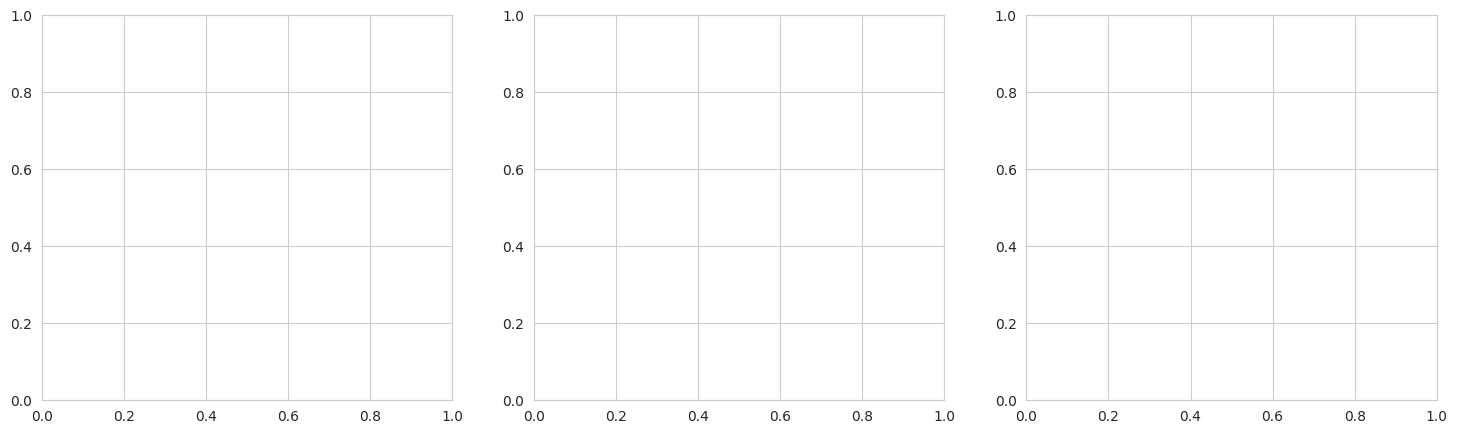

In [ ]:
print("\n  → Creating Optuna optimization history visualization...")
print("    → Setting up figure with 1x3 subplot layout...")

# Plot Optuna optimization history for each model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
print("    ✓ Figure created")

studies = [
    (study_xgb, 'XGBoost', axes[0]),
    (study_cb, 'CatBoost', axes[1]),
    (study_lgb, 'LightGBM', axes[2])
]
print(f"    → Preparing to plot {len(studies)} optimization histories...")

for study, name, ax in studies:
    print(f"    → Plotting {name} optimization history...")
    trials = study.trials_dataframe()
    print(f"      ✓ Trials data extracted: {len(trials)} trials")

    ax.plot(trials['number'], trials['value'], marker='o', linestyle='-', alpha=0.6)
    ax.axhline(y=study.best_value, color='r', linestyle='--', label=f'Best: {study.best_value:.4f}')
    ax.set_xlabel('Trial Number', fontsize=11, fontweight='bold')
    ax.set_ylabel('Weighted F1-Score', fontsize=11, fontweight='bold')
    ax.set_title(f'{name} Optimization History', fontsize=12, fontweight='bold', pad=10)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    print(f"      ✓ {name} optimization history plotted")

print("    → Saving Optuna optimization history chart...")
plt.suptitle('Optuna Hyperparameter Optimization History', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Optuna_Optimization_History.png', dpi=300, bbox_inches='tight')
print("    ✓ File saved successfully")
plt.close()
print("    ✓ Figure closed")

print("\n✓ Optuna optimization history saved: Optuna_Optimization_History.png")


## 9. Save Models and Results


In [ ]:
print("\nSaving models and results...")
print("  → Starting save process...")

# Save individual models
print("\n  → Saving individual models...")
print("    → Saving XGBoost model...")
joblib.dump(xgb_model, 'xgboost_ensemble_model.pkl')
print("    ✓ XGBoost model saved: xgboost_ensemble_model.pkl")

print("    → Saving CatBoost model...")
joblib.dump(cb_model, 'catboost_ensemble_model.pkl')
print("    ✓ CatBoost model saved: catboost_ensemble_model.pkl")

print("    → Saving LightGBM model...")
joblib.dump(lgb_model, 'lightgbm_ensemble_model.pkl')
print("    ✓ LightGBM model saved: lightgbm_ensemble_model.pkl")

# Save ensemble model
print("\n  → Saving ensemble model...")
joblib.dump(ensemble_model, 'ensemble_attack_model.pkl')
print("  ✓ Ensemble model saved: ensemble_attack_model.pkl")

# Save encoders
print("\n  → Saving encoders...")
print("    → Saving target encoder...")
joblib.dump(target_encoder, 'target_encoder_ensemble.pkl')
print("    ✓ Target encoder saved: target_encoder_ensemble.pkl")

if label_encoders:
    print("    → Saving feature encoders...")
    joblib.dump(label_encoders, 'feature_encoders_ensemble.pkl')
    print(f"    ✓ Feature encoders saved: feature_encoders_ensemble.pkl ({len(label_encoders)} encoders)")
else:
    print("    → No feature encoders to save")

# Save best hyperparameters
print("\n  → Saving best hyperparameters...")
import json

hyperparameters = {
    'xgboost': best_params_xgb,
    'catboost': best_params_cb,
    'lightgbm': best_params_lgb
}

with open('best_hyperparameters.json', 'w') as f:
    json.dump(hyperparameters, f, indent=2, default=str)
print("  ✓ Best hyperparameters saved: best_hyperparameters.json")

# Save feature importance
print("\n  → Saving feature importance files...")
print("    → Saving XGBoost feature importance...")
feature_importance_xgb.to_csv('feature_importance_xgboost.csv', index=False)
print("    ✓ XGBoost feature importance saved")

print("    → Saving CatBoost feature importance...")
feature_importance_cb.to_csv('feature_importance_catboost.csv', index=False)
print("    ✓ CatBoost feature importance saved")

print("    → Saving LightGBM feature importance...")
feature_importance_lgb.to_csv('feature_importance_lightgbm.csv', index=False)
print("    ✓ LightGBM feature importance saved")

print("    → Saving feature importance comparison...")
importance_comparison.to_csv('feature_importance_comparison.csv', index=False)
print("    ✓ Feature importance comparison saved")

print("  ✓ All feature importance files saved")

# Save results summary
print("\n  → Saving results summary...")
results_summary = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[name]['accuracy'] for name in results.keys()],
    'Weighted_F1': [results[name]['f1_weighted'] for name in results.keys()],
    'Macro_F1': [results[name]['f1_macro'] for name in results.keys()]
})
results_summary.to_csv('model_results_summary.csv', index=False)
print("  ✓ Results summary saved: model_results_summary.csv")

print("\n✓ All models and results saved successfully!")
print("  → Save process completed!")



Saving models and results...
  → Starting save process...

  → Saving individual models...
    → Saving XGBoost model...
    ✓ XGBoost model saved: xgboost_ensemble_model.pkl
    → Saving CatBoost model...
    ✓ CatBoost model saved: catboost_ensemble_model.pkl
    → Saving LightGBM model...
    ✓ LightGBM model saved: lightgbm_ensemble_model.pkl

  → Saving ensemble model...
  ✓ Ensemble model saved: ensemble_attack_model.pkl

  → Saving encoders...
    → Saving target encoder...
    ✓ Target encoder saved: target_encoder_ensemble.pkl
    → No feature encoders to save

  → Saving best hyperparameters...
  ✓ Best hyperparameters saved: best_hyperparameters.json

  → Saving feature importance files...
    → Saving XGBoost feature importance...
    ✓ XGBoost feature importance saved
    → Saving CatBoost feature importance...
    ✓ CatBoost feature importance saved
    → Saving LightGBM feature importance...
    ✓ LightGBM feature importance saved
    → Saving feature importance compari

## 10. Final Summary


In [ ]:
print("\n" + "="*70)
print("ENSEMBLE MODEL TRAINING COMPLETED!")
print("="*70)

print(f"\nDataset Information:")
print(f"  - Total records: {len(df):,}")
print(f"  - Train set: {len(X_train_final):,} records")
print(f"  - Test set: {len(X_test):,} records")
print(f"  - Number of features: {X.shape[1]}")
print(f"  - Number of classes: {target.nunique()}")

print(f"\nOptuna Tuning Results:")
if 'study_xgb' in globals() and hasattr(study_xgb, 'best_value'):
    print(f"  - XGBoost best F1: {study_xgb.best_value:.4f} ({optuna_time_xgb:.2f}s)")
else:
    print(f"  - XGBoost best F1: Not available (tuning not completed)")

if 'study_cb' in globals() and hasattr(study_cb, 'best_value'):
    print(f"  - CatBoost best F1: {study_cb.best_value:.4f} ({optuna_time_cb:.2f}s)")
else:
    print(f"  - CatBoost best F1: Not available (tuning not completed)")

if 'study_lgb' in globals() and hasattr(study_lgb, 'best_value'):
    print(f"  - LightGBM best F1: {study_lgb.best_value:.4f} ({optuna_time_lgb:.2f}s)")
else:
    print(f"  - LightGBM best F1: Not available (tuning not completed)")

print(f"\nModel Training Times:")
print(f"  - XGBoost: {train_time_xgb:.2f} seconds")
print(f"  - CatBoost: {train_time_cb:.2f} seconds")
print(f"  - LightGBM: {train_time_lgb:.2f} seconds")
print(f"  - Total: {train_time_xgb + train_time_cb + train_time_lgb:.2f} seconds")

print(f"\nTest Set Performance:")
print(f"{'Model':<15} {'Accuracy':<15} {'Weighted F1':<15} {'Macro F1':<15}")
print("-" * 70)
for name in ['XGBoost', 'CatBoost', 'LightGBM', 'Ensemble']:
    print(f"{name:<15} {results[name]['accuracy']*100:<14.4f}% {results[name]['f1_weighted']:<15.4f} {results[name]['f1_macro']:<15.4f}")

print(f"\nGenerated Files:")
print(f"  ✓ ensemble_attack_model.pkl")
print(f"  ✓ xgboost_ensemble_model.pkl")
print(f"  ✓ catboost_ensemble_model.pkl")
print(f"  ✓ lightgbm_ensemble_model.pkl")
print(f"  ✓ target_encoder_ensemble.pkl")
print(f"  ✓ best_hyperparameters.json")
print(f"  ✓ Confusion_Matrices_Ensemble.png")
print(f"  ✓ Model_Performance_Comparison.png")
print(f"  ✓ Feature_Importance_Comparison.png")
print(f"  ✓ Optuna_Optimization_History.png")
print(f"  ✓ model_results_summary.csv")
print(f"  ✓ feature_importance_*.csv")

print(f"\n{'='*70}")
print("Analysis Complete!")
print(f"{'='*70}")



ENSEMBLE MODEL TRAINING COMPLETED!

Dataset Information:
  - Total records: 13,128,158
  - Train set: 10,502,526 records
  - Test set: 2,625,632 records
  - Number of features: 41
  - Number of classes: 9

Optuna Tuning Results:
  - XGBoost best F1: Not available (tuning not completed)
  - CatBoost best F1: Not available (tuning not completed)
  - LightGBM best F1: Not available (tuning not completed)

Model Training Times:
  - XGBoost: 534.42 seconds
  - CatBoost: 8424.83 seconds
  - LightGBM: 764.26 seconds
  - Total: 9723.51 seconds

Test Set Performance:
Model           Accuracy        Weighted F1     Macro F1       
----------------------------------------------------------------------
XGBoost         97.4343       % 0.9743          0.9648         
CatBoost        97.2254       % 0.9722          0.9631         
LightGBM        97.7267       % 0.9772          0.9690         
Ensemble        97.5925       % 0.9759          0.9675         

Generated Files:
  ✓ ensemble_attack_model

In [49]:
!cp -r /content/sample_data/ /content/Drive/MyDrive/Collab+Sonuc
